# Clustering Exploration

This notebook explores how different slab, weak-layer, and Extended Column Test (ECT) feature choices change two-cluster K-means results in the SnowPylot dataset. The workflow is intentionally linear: load CAAML pits, build slabs from the layer of concern, derive slab/weak-layer/ECT features, then compare a fixed two-cluster workflow across multiple feature sets.

The main question is whether a feature set produces a clear K=2 separation and concentrates pits marked as near an avalanche in one cluster. Pits marked near an avalanche are treated as known unstable examples. Pits not marked near an avalanche are treated as unlabeled/unknown context, not as stable negatives.

The primary comparison uses a common sample across the main physical and ECT feature sets so feature-set rankings are not driven by different complete-case row sets. Natural-retention results are kept as a coverage and applicability diagnostic. PCA is reserved for an optional appendix-style interpretation check and is not used to rank feature sets.


## Setup

All imports, paths, model settings, feature-set definitions, and display labels live here so the rest of the notebook reads like an analysis narrative. Feature sets are organized into primary comparison sets and low-coverage sensitivity sets. The primary common-sample comparison includes slab, weak-layer, log-transform, and ECT feature sets; D11 is retained only as a natural-retention sensitivity check.


In [1]:
import re
import sys
import warnings
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR
    NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"

SNOWPYT_MECHPARAMS_SRC = PROJECT_ROOT.parent / "SnowPyt-MechParams" / "src"
for import_path in [NOTEBOOK_DIR, SNOWPYT_MECHPARAMS_SRC]:
    import_path_text = str(import_path)
    if import_path.exists() and import_path_text not in sys.path:
        sys.path.insert(0, import_path_text)

from caaml_utils import parse_caaml_directory
from snowpyt_mechparams.execution import ExecutionEngine
from snowpyt_mechparams.models import Pit

try:
    from tqdm.auto import tqdm
except ImportError:

    def tqdm(items, **_kwargs):
        return items

warnings.filterwarnings(
    "ignore",
    message="Using UFloat objects with std_dev==0 may give unexpected results.",
)

sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = PROJECT_ROOT / "snowpits" / "2015_2025"
RANDOM_STATE = 42
KMEANS_N_CLUSTERS = 2
ECT_MAX_TAPS = 31.0
CLUSTER_ORDER_COLUMN = "slab_weight_N_m2"
PERMUTATION_N_ITERATIONS = 1000

ANALYSIS_METADATA_COLUMNS = [
    "pit_id",
    "slab_id",
    "near_avalanche_flag",
    "near_avalanche_raw",
    "near_avalanche_status",
]

FEATURE_SET_DEFINITIONS = {
    "slab_load": [
        "slab_thickness_cm",
        "slab_weight_N_m2",
    ],
    "weak_layer_core": [
        "weak_layer_depth_top_cm",
        "weak_layer_thickness_cm",
        "weak_layer_hhi",
        "weak_layer_persistent_grain",
    ],
    "slab_plus_weak_layer": [
        "slab_thickness_cm",
        "slab_weight_N_m2",
        "n_layers",
        "cumulative_hhi_cm",
        "slab_mean_hhi",
        "weak_layer_depth_top_cm",
        "weak_layer_thickness_cm",
        "weak_layer_hhi",
        "weak_layer_persistent_grain",
    ],
    "log_transform_sensitivity": [
        "log1p_slab_thickness_cm",
        "log1p_slab_weight_N_m2",
        "n_layers",
        "log1p_cumulative_hhi_cm",
        "log1p_slab_mean_hhi",
        "log1p_weak_layer_depth_top_cm",
        "log1p_weak_layer_thickness_cm",
        "log1p_weak_layer_hhi",
        "weak_layer_persistent_grain",
    ],
    "ect_response_sensitivity": [
        "ect_propagation_rate",
        "ect_mean_taps",
        "ect_mean_propagating_taps",
        "ect_instability_index",
    ],
    "slab_weak_layer_plus_ect": [
        "slab_thickness_cm",
        "slab_weight_N_m2",
        "n_layers",
        "cumulative_hhi_cm",
        "slab_mean_hhi",
        "weak_layer_depth_top_cm",
        "weak_layer_thickness_cm",
        "weak_layer_hhi",
        "weak_layer_persistent_grain",
        "ect_propagation_rate",
        "ect_mean_taps",
        "ect_mean_propagating_taps",
        "ect_instability_index",
    ],
    "d11_sensitivity": [
        "slab_thickness_cm",
        "slab_weight_N_m2",
        "n_layers",
        "cumulative_hhi_cm",
        "slab_mean_hhi",
        "bending_stiffness_D11_N_mm",
    ],
    "slab_weak_layer_d11_sensitivity": [
        "slab_thickness_cm",
        "slab_weight_N_m2",
        "n_layers",
        "cumulative_hhi_cm",
        "slab_mean_hhi",
        "weak_layer_depth_top_cm",
        "weak_layer_thickness_cm",
        "weak_layer_hhi",
        "weak_layer_persistent_grain",
        "bending_stiffness_D11_N_mm",
    ],
}

PRIMARY_FEATURE_SET_NAMES = [
    "slab_load",
    "weak_layer_core",
    "slab_plus_weak_layer",
    "log_transform_sensitivity",
    "ect_response_sensitivity",
    "slab_weak_layer_plus_ect",
]
SENSITIVITY_FEATURE_SET_NAMES = [
    "d11_sensitivity",
    "slab_weak_layer_d11_sensitivity",
]


FORBIDDEN_CLUSTERING_FEATURE_COLUMNS = set(ANALYSIS_METADATA_COLUMNS) | {
    "near_avalanche",
    "near_avalanche_label",
    "pit_date",
    "season",
    "month",
    "operation_name",
    "country",
    "region",
    "elevation",
    "slope_angle",
    "aspect",
}
LOG_TRANSFORM_SOURCE_COLUMNS = [
    "slab_thickness_cm",
    "slab_weight_N_m2",
    "cumulative_hhi_cm",
    "slab_mean_hhi",
    "weak_layer_depth_top_cm",
    "weak_layer_thickness_cm",
    "weak_layer_hhi",
]

COVERAGE_FEATURE_COLUMNS = [
    "slab_thickness_cm",
    "slab_weight_N_m2",
    "n_layers",
    "cumulative_hhi_cm",
    "slab_mean_hhi",
    "weak_layer_depth_top_cm",
    "weak_layer_thickness_cm",
    "weak_layer_hhi",
    "weak_layer_persistent_grain",
    "bending_stiffness_D11_N_mm",
    "ect_propagation_rate",
    "ect_mean_taps",
    "ect_mean_propagating_taps",
    "ect_instability_index",
    "ect_count",
    "ect_parsed_count",
]
FEATURE_DISPLAY_NAMES = {
    "slab_thickness_cm": "Slab thickness (cm)",
    "slab_weight_N_m2": "Slab weight (N/m2)",
    "n_layers": "Slab layer count",
    "cumulative_hhi_cm": "Cumulative HHI (cm)",
    "slab_mean_hhi": "Thickness-weighted mean slab HHI",
    "weak_layer_depth_top_cm": "Weak-layer top depth (cm)",
    "weak_layer_thickness_cm": "Weak-layer thickness (cm)",
    "weak_layer_hhi": "Weak-layer HHI",
    "weak_layer_persistent_grain": "Weak-layer persistent grain flag",
    "bending_stiffness_D11_N_mm": "Bending stiffness D11 (N mm)",
    "ect_propagation_rate": "ECT propagation rate",
    "ect_mean_taps": "ECT mean taps",
    "ect_mean_propagating_taps": "ECT mean propagating taps",
    "ect_instability_index": "ECT instability index",
    "ect_count": "ECT count",
    "ect_parsed_count": "Parsed ECT count",
}
for source_column in LOG_TRANSFORM_SOURCE_COLUMNS:
    FEATURE_DISPLAY_NAMES[f"log1p_{source_column}"] = (
        f"log1p {FEATURE_DISPLAY_NAMES[source_column]}"
    )

WEIGHT_METHODS = {
    "density": "kim_jamieson_table2",
    "slab_weight": "sum_layer_weight",
}
D11_METHODS = {
    "density": "kim_jamieson_table2",
    "elastic_modulus": "schottner",
    "poissons_ratio": "kochle",
    "D11": "weissgraeber_rosendahl",
}

pd.options.display.float_format = "{:,.3f}".format

## Helper Functions

These helpers keep the analysis cells short. They handle uncertain values, missing values, avalanche-context labels, slab-level hand-hardness summaries, ECT score parsing, and permutation diagnostics.

In [2]:
def nominal_value(value):
    """Return a finite float from a scalar, unit tuple/list, or uncertainties value."""
    if value is None:
        return np.nan
    if isinstance(value, (list, tuple)):
        if not value:
            return np.nan
        value = value[0]
    value = getattr(value, "nominal_value", value)
    try:
        value = float(value)
    except (TypeError, ValueError):
        return np.nan
    return value if np.isfinite(value) else np.nan


def near_avalanche_status_from_raw(value):
    """Keep true, false, and missing avalanche context distinct."""
    if value is True:
        return "Near avalanche"
    if value is False:
        return "Explicitly not near avalanche"
    return "Unknown/not recorded"


def cumulative_hhi_cm(slab):
    """Sum layer hand hardness index multiplied by layer thickness in cm."""
    total = 0.0
    for layer in slab.layers:
        hhi = nominal_value(layer.hand_hardness_index)
        thickness = nominal_value(layer.thickness)
        if np.isnan(hhi) or np.isnan(thickness):
            return np.nan
        total += hhi * thickness
    return total


def slab_mean_hhi(slab):
    """Return thickness-weighted mean slab hand hardness index."""
    cumulative_hhi = cumulative_hhi_cm(slab)
    slab_thickness = nominal_value(slab.total_thickness)
    if np.isnan(cumulative_hhi) or np.isnan(slab_thickness) or slab_thickness <= 0:
        return np.nan
    return cumulative_hhi / slab_thickness


def weak_layer_persistent_grain_flag(weak_layer):
    """Flag depth hoar, facets, or surface hoar weak layers."""
    if weak_layer is None:
        return np.nan
    grain_form = getattr(weak_layer, "main_grain_form", None)
    if grain_form is None:
        raw_grain_form = getattr(weak_layer, "grain_form", None)
        grain_form = str(raw_grain_form)[:2] if raw_grain_form is not None else None
    if grain_form is None:
        return np.nan
    return float(str(grain_form).upper() in {"DH", "FC", "SH"})


def log1p_positive(series):
    """Return log1p for non-negative finite values and NaN otherwise."""
    numeric_series = pd.to_numeric(series, errors="coerce")
    return np.where(numeric_series >= 0, np.log1p(numeric_series), np.nan)


def mean_or_nan(values):
    """Return the mean of finite values, or NaN when no finite values exist."""
    valid_values = [value for value in values if not np.isnan(value)]
    return float(np.mean(valid_values)) if valid_values else np.nan


def parse_ect_result(ect):
    """Parse one ECT result into propagation, tap count, depth, and instability score."""
    score = (getattr(ect, "test_score", None) or "").strip().upper()
    propagation = np.nan
    taps = np.nan
    depth_top = nominal_value(getattr(ect, "depth_top", None))

    # ECTPV is propagation during isolation. ECTX is treated as non-propagating
    # at the maximum score so tap-based summaries stay on the ECT 0-31 scale.
    if score == "ECTPV":
        propagation = 1.0
        taps = 0.0
    elif score == "ECTX":
        propagation = 0.0
        taps = ECT_MAX_TAPS
    elif score.startswith("ECT") and len(score) >= 4:
        propagation_code = score[3]
        if propagation_code == "P":
            propagation = 1.0
        elif propagation_code in {"N", "X"}:
            propagation = 0.0

        tap_match = re.search(r"\d+", score[4:] if len(score) > 4 else "")
        if tap_match:
            taps = float(tap_match.group(0))
    elif getattr(ect, "propagation", None) is not None:
        propagation = 1.0 if ect.propagation else 0.0

    if np.isnan(taps) and getattr(ect, "num_taps", None) is not None:
        tap_match = re.search(r"\d+", str(ect.num_taps))
        if tap_match:
            taps = float(tap_match.group(0))

    if np.isnan(propagation):
        instability = np.nan
    elif propagation == 0.0:
        instability = 0.0
    elif np.isnan(taps):
        instability = np.nan
    else:
        instability = float(np.clip((ECT_MAX_TAPS - taps) / ECT_MAX_TAPS, 0.0, 1.0))

    return {
        "score": score,
        "propagation": propagation,
        "taps": taps,
        "depth_top": depth_top,
        "instability": instability,
    }


def summarize_ect_results(ect_results):
    """Summarize all ECT results attached to a slab."""
    parsed_results = [parse_ect_result(ect) for ect in ect_results]
    propagation_values = [result["propagation"] for result in parsed_results]
    tap_values = [result["taps"] for result in parsed_results]
    depth_values = [result["depth_top"] for result in parsed_results]
    instability_values = [result["instability"] for result in parsed_results]
    propagating_taps = [
        result["taps"]
        for result in parsed_results
        if result["propagation"] == 1.0 and not np.isnan(result["taps"])
    ]
    parsed_count = sum(
        not np.isnan(result["propagation"]) or not np.isnan(result["taps"])
        for result in parsed_results
    )

    return {
        "ect_count": len(ect_results),
        "ect_parsed_count": parsed_count,
        "ect_propagation_rate": mean_or_nan(propagation_values),
        "ect_mean_taps": mean_or_nan(tap_values),
        "ect_mean_propagating_taps": mean_or_nan(propagating_taps),
        "ect_mean_depth_top_cm": mean_or_nan(depth_values),
        "ect_instability_index": mean_or_nan(instability_values),
        "has_ECT": len(ect_results) > 0,
        "has_ECT_features": parsed_count > 0,
    }


def between_cluster_rate_difference(
    clustered_df,
    label_column="near_avalanche_flag",
    cluster_column="cluster",
):
    """Return the absolute difference in near-avalanche rates between two clusters."""
    rates = clustered_df.groupby(cluster_column)[label_column].mean()
    if len(rates) < 2:
        return np.nan
    return float((rates.max() - rates.min()) * 100)


def permutation_rate_difference_p_value(clustered_df, cluster_column="cluster"):
    """Estimate whether the cluster rate difference exceeds random label assignment."""
    observed_difference = between_cluster_rate_difference(
        clustered_df,
        cluster_column=cluster_column,
    )
    if np.isnan(observed_difference):
        return np.nan

    labels = clustered_df["near_avalanche_flag"].astype(float).to_numpy()
    if labels.sum() == 0 or labels.sum() == len(labels):
        return np.nan

    rng = np.random.default_rng(RANDOM_STATE)
    cluster_ids = clustered_df[cluster_column].to_numpy()
    permuted_differences = []
    for _ in range(PERMUTATION_N_ITERATIONS):
        permuted_df = pd.DataFrame(
            {
                cluster_column: cluster_ids,
                "near_avalanche_flag": rng.permutation(labels),
            }
        )
        permuted_differences.append(
            between_cluster_rate_difference(
                permuted_df,
                cluster_column=cluster_column,
            )
        )

    return float(
        (np.sum(np.array(permuted_differences) >= observed_difference) + 1)
        / (PERMUTATION_N_ITERATIONS + 1)
    )


## Data Loading

Parse the CAAML files, then convert SnowPylot pits into SnowPyt-MechParams pit objects for slab creation and mechanical-property calculations.


In [3]:
raw_pits = parse_caaml_directory(DATA_DIR)
mech_pits = [Pit.from_snow_pit(pit) for pit in raw_pits]

loading_summary_df = pd.DataFrame(
    {
        "metric": ["CAAML directory", "Parsed SnowPylot pits", "Converted mech pits"],
        "value": [str(DATA_DIR), f"{len(raw_pits):,}", f"{len(mech_pits):,}"],
    }
)
loading_summary_df


,metric,value
0,CAAML directory,/Users/marykate/Desktop/Snow/snowpylot-applica...
1,Parsed SnowPylot pits,"50,278"
2,Converted mech pits,"50,278"


## Slab And Weak-Layer Feature Engineering

Each slab is created from the layer of concern. The feature table keeps identifiers, the original near-avalanche marker, an explicit avalanche-context status, slab load/structure features, core weak-layer features, and D11 for low-coverage sensitivity analysis.

In [4]:
slab_records = []

for raw_pit, mech_pit in zip(raw_pits, mech_pits):
    location = raw_pit.core_info.location
    near_avalanche_raw = location.pit_near_avalanche
    near_avalanche_status = near_avalanche_status_from_raw(near_avalanche_raw)
    ect_results = raw_pit.stability_tests.ECT if raw_pit.stability_tests else []

    for slab in mech_pit.create_slabs(weak_layer_def="layer_of_concern"):
        slab_records.append(
            {
                "pit_id": mech_pit.pit_id,
                "near_avalanche_flag": near_avalanche_raw is True,
                "near_avalanche_raw": near_avalanche_raw,
                "near_avalanche_status": near_avalanche_status,
                "slab": slab,
                "slab_layers": slab.layers,
                "snow_pit": raw_pit,
                "mech_pit": mech_pit,
                "ect_results": ect_results,
            }
        )

slab_status_counts_df = pd.Series(
    [record["near_avalanche_status"] for record in slab_records],
    name="near_avalanche_status",
).value_counts(dropna=False).rename_axis("near_avalanche_status").reset_index(name="slab_count")

slab_summary_df = pd.DataFrame(
    {
        "metric": ["Usable slabs", "Slabs marked near avalanche"],
        "value": [
            f"{len(slab_records):,}",
            f"{sum(record['near_avalanche_flag'] for record in slab_records):,}",
        ],
    }
)

display(slab_summary_df)
slab_status_counts_df

,metric,value
0,Usable slabs,"34,690"
1,Slabs marked near avalanche,"1,381"


,near_avalanche_status,slab_count
0,Unknown/not recorded,33309
1,Near avalanche,1381


In [5]:
engine = ExecutionEngine()
feature_records = []

for slab_record in tqdm(slab_records, desc="Creating slab features", unit="slab"):
    slab = slab_record["slab"]
    weak_layer = slab.weak_layer

    weight_result = engine.execute_single(slab, "slab_weight", WEIGHT_METHODS)
    slab_weight = (
        nominal_value(weight_result.slab.slab_weight)
        if weight_result is not None and weight_result.success
        else np.nan
    )

    d11_result = engine.execute_single(slab, "D11", D11_METHODS)
    bending_stiffness = (
        nominal_value(d11_result.slab.D11)
        if d11_result is not None and d11_result.success
        else np.nan
    )

    feature_records.append(
        {
            "pit_id": slab_record["pit_id"],
            "slab_id": slab.slab_id,
            "near_avalanche_flag": slab_record["near_avalanche_flag"],
            "near_avalanche_raw": slab_record["near_avalanche_raw"],
            "near_avalanche_status": slab_record["near_avalanche_status"],
            "n_layers": len(slab.layers),
            "slab_thickness_cm": nominal_value(slab.total_thickness),
            "slab_weight_N_m2": slab_weight,
            "bending_stiffness_D11_N_mm": bending_stiffness,
            "cumulative_hhi_cm": cumulative_hhi_cm(slab),
            "slab_mean_hhi": slab_mean_hhi(slab),
            "weak_layer_depth_top_cm": nominal_value(
                getattr(weak_layer, "depth_top", None)
            ),
            "weak_layer_thickness_cm": nominal_value(
                getattr(weak_layer, "thickness", None)
            ),
            "weak_layer_hhi": nominal_value(
                getattr(weak_layer, "hand_hardness_index", None)
            ),
            "weak_layer_persistent_grain": weak_layer_persistent_grain_flag(weak_layer),
        }
    )

slab_features_df = pd.DataFrame(feature_records)

feature_coverage_df = pd.DataFrame(
    {
        "feature": [
            column
            for column in COVERAGE_FEATURE_COLUMNS
            if column in slab_features_df.columns
        ],
    }
)
feature_coverage_df["display_name"] = feature_coverage_df["feature"].map(
    FEATURE_DISPLAY_NAMES
)
feature_coverage_df["non_null_count"] = [
    slab_features_df[column].notna().sum()
    for column in feature_coverage_df["feature"]
]
feature_coverage_df["coverage"] = [
    slab_features_df[column].notna().mean()
    for column in feature_coverage_df["feature"]
]
feature_coverage_df

,feature,display_name,non_null_count,coverage
0,slab_thickness_cm,Slab thickness (cm),34690,1.000
1,slab_weight_N_m2,Slab weight (N/m2),14796,0.427
2,n_layers,Slab layer count,34690,1.000
3,cumulative_hhi_cm,Cumulative HHI (cm),25027,0.721
4,slab_mean_hhi,Thickness-weighted mean slab HHI,25027,0.721
5,weak_layer_depth_top_cm,Weak-layer top depth (cm),34690,1.000
6,weak_layer_thickness_cm,Weak-layer thickness (cm),34690,1.000
7,weak_layer_hhi,Weak-layer HHI,31316,0.903
8,weak_layer_persistent_grain,Weak-layer persistent grain flag,31663,0.913
9,bending_stiffness_D11_N_mm,Bending stiffness D11 (N mm),1590,0.046


## ECT Features

ECT strings are converted into numerical summaries for sensitivity feature sets. Propagating tests with fewer taps receive a higher instability score; non-propagating tests receive zero. Rows with unparseable ECT data keep missing values and are filtered out only for feature sets that include ECT variables. The parser QA table below makes the score rules explicit before those features are used.

In [6]:
# Quick parser QA for common ECT encodings before applying the parser to the corpus.
ect_parser_examples = [
    SimpleNamespace(test_score="ECTPV", num_taps=None, depth_top=[10.0, "cm"]),
    SimpleNamespace(test_score="ECTX", num_taps=None, depth_top=[10.0, "cm"]),
    SimpleNamespace(test_score="ECTP12", num_taps=None, depth_top=[10.0, "cm"]),
    SimpleNamespace(test_score="ECTN4", num_taps=None, depth_top=[10.0, "cm"]),
    SimpleNamespace(test_score="ECTN25", num_taps=None, depth_top=[10.0, "cm"]),
    SimpleNamespace(test_score="bad score", num_taps=None, depth_top=[10.0, "cm"]),
    SimpleNamespace(test_score=None, num_taps=None, depth_top=None),
]
ect_parser_qa_df = pd.DataFrame(
    [parse_ect_result(ect_example) for ect_example in ect_parser_examples]
)

ect_feature_records = [
    summarize_ect_results(slab_record["ect_results"])
    for slab_record in slab_records
]
ect_features_df = pd.DataFrame(ect_feature_records)

slab_features_df = pd.concat(
    [slab_features_df.reset_index(drop=True), ect_features_df],
    axis=1,
)

for source_column in LOG_TRANSFORM_SOURCE_COLUMNS:
    slab_features_df[f"log1p_{source_column}"] = log1p_positive(
        slab_features_df[source_column]
    )

feature_coverage_df = pd.DataFrame(
    {
        "feature": [
            column
            for column in COVERAGE_FEATURE_COLUMNS
            if column in slab_features_df.columns
        ],
    }
)
feature_coverage_df["display_name"] = feature_coverage_df["feature"].map(
    FEATURE_DISPLAY_NAMES
)
feature_coverage_df["non_null_count"] = [
    slab_features_df[column].notna().sum()
    for column in feature_coverage_df["feature"]
]
feature_coverage_df["coverage"] = [
    slab_features_df[column].notna().mean()
    for column in feature_coverage_df["feature"]
]
feature_coverage_df["used_in_any_feature_set"] = [
    any(column in feature_columns for feature_columns in FEATURE_SET_DEFINITIONS.values())
    for column in feature_coverage_df["feature"]
]
feature_coverage_df["low_coverage_sensitivity_feature"] = (
    feature_coverage_df["used_in_any_feature_set"]
    & feature_coverage_df["feature"].str.contains("ect_|D11", regex=True)
)
ect_coverage_df = pd.DataFrame(
    {
        "metric": ["Slabs with ECT results", "Slabs with parsed ECT features"],
        "value": [
            int(slab_features_df["has_ECT"].sum()),
            int(slab_features_df["has_ECT_features"].sum()),
        ],
    }
)

feature_set_definition_df = pd.DataFrame(
    [
        {
            "feature_set": feature_set_name,
            "n_features": len(feature_columns),
            "features": ", ".join(feature_columns),
        }
        for feature_set_name, feature_columns in FEATURE_SET_DEFINITIONS.items()
    ]
)

display(ect_parser_qa_df)
display(ect_coverage_df)
display(feature_coverage_df)
feature_set_definition_df

,score,propagation,taps,depth_top,instability
0,ECTPV,1.000,0.000,10.000,1.000
1,ECTX,0.000,31.000,10.000,0.000
2,ECTP12,1.000,12.000,10.000,0.613
3,ECTN4,0.000,4.000,10.000,0.000
4,ECTN25,0.000,25.000,10.000,0.000
5,BAD SCORE,NaN,NaN,10.000,NaN
6,,NaN,NaN,NaN,NaN


,metric,value
0,Slabs with ECT results,25010
1,Slabs with parsed ECT features,19397


,feature,display_name,non_null_count,coverage,used_in_any_feature_set,low_coverage_sensitivity_feature
0,slab_thickness_cm,Slab thickness (cm),34690,1.000,True,False
1,slab_weight_N_m2,Slab weight (N/m2),14796,0.427,True,False
2,n_layers,Slab layer count,34690,1.000,True,False
3,cumulative_hhi_cm,Cumulative HHI (cm),25027,0.721,True,False
4,slab_mean_hhi,Thickness-weighted mean slab HHI,25027,0.721,True,False
5,weak_layer_depth_top_cm,Weak-layer top depth (cm),34690,1.000,True,False
6,weak_layer_thickness_cm,Weak-layer thickness (cm),34690,1.000,True,False
7,weak_layer_hhi,Weak-layer HHI,31316,0.903,True,False
8,weak_layer_persistent_grain,Weak-layer persistent grain flag,31663,0.913,True,False
9,bending_stiffness_D11_N_mm,Bending stiffness D11 (N mm),1590,0.046,True,True


,feature_set,n_features,features
0,slab_load,2,"slab_thickness_cm, slab_weight_N_m2"
1,weak_layer_core,4,"weak_layer_depth_top_cm, weak_layer_thickness_..."
2,slab_plus_weak_layer,9,"slab_thickness_cm, slab_weight_N_m2, n_layers,..."
3,log_transform_sensitivity,9,"log1p_slab_thickness_cm, log1p_slab_weight_N_m..."
4,ect_response_sensitivity,4,"ect_propagation_rate, ect_mean_taps, ect_mean_..."
5,slab_weak_layer_plus_ect,13,"slab_thickness_cm, slab_weight_N_m2, n_layers,..."
6,d11_sensitivity,6,"slab_thickness_cm, slab_weight_N_m2, n_layers,..."
7,slab_weak_layer_d11_sensitivity,10,"slab_thickness_cm, slab_weight_N_m2, n_layers,..."


## Feature-Set K-Means Analysis

Each feature set is analyzed with complete-case filtering, standardization, and fixed two-cluster K-means. The primary result uses one shared complete-case sample across the main physical and ECT feature sets. Natural-retention results are shown separately so missing-data effects remain visible. Cluster roles are assigned by the held-out near-avalanche rate after clustering: the cluster with the higher near-avalanche rate is labeled as the enriched cluster.


In [7]:
def validate_feature_sets(feature_sets, available_columns):
    """Validate that feature sets use available, non-forbidden columns."""
    missing_features = {
        feature_set_name: sorted(set(feature_columns) - set(available_columns))
        for feature_set_name, feature_columns in feature_sets.items()
    }
    missing_features = {
        feature_set_name: missing
        for feature_set_name, missing in missing_features.items()
        if missing
    }
    if missing_features:
        raise ValueError(f"Feature sets reference missing columns: {missing_features}")

    forbidden_features = {
        feature_set_name: sorted(set(feature_columns) & FORBIDDEN_CLUSTERING_FEATURE_COLUMNS)
        for feature_set_name, feature_columns in feature_sets.items()
    }
    forbidden_features = {
        feature_set_name: forbidden
        for feature_set_name, forbidden in forbidden_features.items()
        if forbidden
    }
    if forbidden_features:
        raise ValueError(
            f"Feature sets include forbidden clustering inputs: {forbidden_features}"
        )


def feature_set_diagnostics(feature_set_name, feature_columns, source_df):
    """Summarize coverage and avalanche-context retention before clustering."""
    complete_feature_mask = source_df[feature_columns].notna().all(axis=1)
    retained_df = source_df.loc[complete_feature_mask]
    status_counts = retained_df["near_avalanche_status"].value_counts(dropna=False)
    uses_ect_features = any(feature.startswith("ect_") for feature in feature_columns)
    uses_d11_features = "bending_stiffness_D11_N_mm" in feature_columns
    return {
        "feature_set": feature_set_name,
        "analysis_group": "primary" if feature_set_name in PRIMARY_FEATURE_SET_NAMES else "sensitivity",
        "n_features": len(feature_columns),
        "total_slabs_before_filtering": len(source_df),
        "total_slabs_retained": len(retained_df),
        "retention_share": len(retained_df) / len(source_df) if len(source_df) else np.nan,
        "near_avalanche_retained": int(retained_df["near_avalanche_flag"].sum()),
        "explicit_not_near_avalanche_retained": int(
            status_counts.get("Explicitly not near avalanche", 0)
        ),
        "unknown_context_retained": int(status_counts.get("Unknown/not recorded", 0)),
        "uses_ect_features": uses_ect_features,
        "uses_d11_features": uses_d11_features,
        "low_coverage_sensitivity": uses_ect_features or uses_d11_features,
    }


def complete_case_mask(source_df, feature_columns):
    """Return the complete-case mask for a set of feature columns."""
    return source_df[feature_columns].notna().all(axis=1)


def enriched_cluster_label(cluster_summary_df):
    """Return the raw K-means label with the highest near-avalanche rate."""
    enriched_row = cluster_summary_df.sort_values(
        ["percent_slabs_near_avalanche", "near_avalanche_slab_count", "slab_count"],
        ascending=[False, False, False],
        kind="mergesort",
    ).iloc[0]
    return enriched_row["cluster"]


def run_feature_set_analysis(
    feature_set_name,
    feature_columns,
    source_df,
    sample_mode,
    row_mask=None,
):
    """Run complete-case scaling and fixed-k K-means for one feature set."""
    selected_columns = list(ANALYSIS_METADATA_COLUMNS) + list(feature_columns)
    if CLUSTER_ORDER_COLUMN not in selected_columns:
        selected_columns.append(CLUSTER_ORDER_COLUMN)
    selected_columns = list(dict.fromkeys(selected_columns))

    if row_mask is None:
        eligible_mask = pd.Series(True, index=source_df.index)
    else:
        eligible_mask = pd.Series(row_mask, index=source_df.index).astype(bool)

    complete_feature_mask = complete_case_mask(source_df, feature_columns)
    analysis_mask = eligible_mask & complete_feature_mask
    analysis_df = source_df.loc[analysis_mask, selected_columns].reset_index(drop=True)

    retained_slabs = len(analysis_df)
    near_avalanche_retained = int(analysis_df["near_avalanche_flag"].sum())
    baseline_near_avalanche_rate = (
        100 * near_avalanche_retained / retained_slabs if retained_slabs else np.nan
    )
    uses_ect_features = any(feature.startswith("ect_") for feature in feature_columns)
    uses_d11_features = "bending_stiffness_D11_N_mm" in feature_columns

    summary_record = {
        "feature_set": feature_set_name,
        "sample_mode": sample_mode,
        "analysis_group": "primary" if feature_set_name in PRIMARY_FEATURE_SET_NAMES else "sensitivity",
        "n_features": len(feature_columns),
        "features": ", ".join(feature_columns),
        "total_slabs_before_filtering": len(source_df),
        "total_slabs_retained": retained_slabs,
        "retention_share": retained_slabs / len(source_df) if len(source_df) else np.nan,
        "near_avalanche_slabs_retained": near_avalanche_retained,
        "baseline_near_avalanche_rate": baseline_near_avalanche_rate,
        "kmeans_silhouette_score": np.nan,
        "enriched_cluster": np.nan,
        "enriched_cluster_slab_count": np.nan,
        "enriched_cluster_near_avalanche_count": np.nan,
        "enriched_cluster_near_avalanche_rate": np.nan,
        "enriched_cluster_rate_lift": np.nan,
        "enriched_cluster_rate_minus_baseline": np.nan,
        "near_avalanche_capture_share": np.nan,
        "enriched_cluster_size_share": np.nan,
        "between_cluster_near_avalanche_rate_difference": np.nan,
        "near_avalanche_rate_permutation_p_value": np.nan,
        "uses_ect_features": uses_ect_features,
        "uses_d11_features": uses_d11_features,
        "low_coverage_sensitivity": uses_ect_features or uses_d11_features,
    }

    if retained_slabs < KMEANS_N_CLUSTERS or len(feature_columns) < 2:
        return {
            "summary": summary_record,
            "cluster_summary": pd.DataFrame(),
            "clustered_slabs": pd.DataFrame(),
        }

    feature_scaler = StandardScaler()
    scaled_feature_values = feature_scaler.fit_transform(
        analysis_df[feature_columns].astype(float)
    )

    try:
        kmeans_model = KMeans(
            n_clusters=KMEANS_N_CLUSTERS,
            random_state=RANDOM_STATE,
            n_init=50,
        )
        cluster_labels = kmeans_model.fit_predict(scaled_feature_values)
        unique_labels = np.unique(cluster_labels)
        if len(unique_labels) > 1 and retained_slabs > len(unique_labels):
            summary_record["kmeans_silhouette_score"] = silhouette_score(
                scaled_feature_values,
                cluster_labels,
            )
    except ValueError:
        return {
            "summary": summary_record,
            "cluster_summary": pd.DataFrame(),
            "clustered_slabs": pd.DataFrame(),
        }

    clustered_slabs_df = analysis_df[ANALYSIS_METADATA_COLUMNS + [CLUSTER_ORDER_COLUMN]].copy()
    clustered_slabs_df["feature_set"] = feature_set_name
    clustered_slabs_df["sample_mode"] = sample_mode
    clustered_slabs_df["cluster"] = cluster_labels

    cluster_summary_df = (
        clustered_slabs_df.groupby(["sample_mode", "feature_set", "cluster"], as_index=False)
        .agg(
            slab_count=("slab_id", "size"),
            near_avalanche_slab_count=("near_avalanche_flag", "sum"),
            mean_slab_weight_N_m2=(CLUSTER_ORDER_COLUMN, "mean"),
        )
    )
    cluster_summary_df["percent_slabs_near_avalanche"] = (
        100
        * cluster_summary_df["near_avalanche_slab_count"]
        / cluster_summary_df["slab_count"]
    )
    cluster_summary_df["feature_set_baseline_near_avalanche_rate"] = baseline_near_avalanche_rate
    cluster_summary_df["near_avalanche_rate_minus_baseline"] = (
        cluster_summary_df["percent_slabs_near_avalanche"]
        - cluster_summary_df["feature_set_baseline_near_avalanche_rate"]
    )
    cluster_summary_df["near_avalanche_rate_lift"] = np.where(
        baseline_near_avalanche_rate > 0,
        cluster_summary_df["percent_slabs_near_avalanche"] / baseline_near_avalanche_rate,
        np.nan,
    )
    cluster_summary_df["near_avalanche_capture_share"] = np.where(
        near_avalanche_retained > 0,
        100 * cluster_summary_df["near_avalanche_slab_count"] / near_avalanche_retained,
        np.nan,
    )
    cluster_summary_df["cluster_size_share"] = (
        100 * cluster_summary_df["slab_count"] / retained_slabs
    )

    enriched_cluster = enriched_cluster_label(cluster_summary_df)
    cluster_summary_df["cluster_role"] = np.where(
        cluster_summary_df["cluster"] == enriched_cluster,
        "Enriched near-avalanche",
        "Other cluster",
    )
    cluster_summary_df = cluster_summary_df.sort_values(
        ["sample_mode", "feature_set", "cluster_role"],
        ascending=[True, True, True],
        kind="mergesort",
    ).reset_index(drop=True)

    enriched_row = cluster_summary_df.loc[
        cluster_summary_df["cluster"] == enriched_cluster
    ].iloc[0]
    summary_record["enriched_cluster"] = int(enriched_cluster)
    summary_record["enriched_cluster_slab_count"] = int(enriched_row["slab_count"])
    summary_record["enriched_cluster_near_avalanche_count"] = int(
        enriched_row["near_avalanche_slab_count"]
    )
    summary_record["enriched_cluster_near_avalanche_rate"] = enriched_row[
        "percent_slabs_near_avalanche"
    ]
    summary_record["enriched_cluster_rate_lift"] = enriched_row["near_avalanche_rate_lift"]
    summary_record["enriched_cluster_rate_minus_baseline"] = enriched_row[
        "near_avalanche_rate_minus_baseline"
    ]
    summary_record["near_avalanche_capture_share"] = enriched_row[
        "near_avalanche_capture_share"
    ]
    summary_record["enriched_cluster_size_share"] = enriched_row["cluster_size_share"]
    summary_record["between_cluster_near_avalanche_rate_difference"] = (
        between_cluster_rate_difference(clustered_slabs_df)
    )
    summary_record["near_avalanche_rate_permutation_p_value"] = (
        permutation_rate_difference_p_value(clustered_slabs_df)
    )

    return {
        "summary": summary_record,
        "cluster_summary": cluster_summary_df,
        "clustered_slabs": clustered_slabs_df,
    }


validate_feature_sets(FEATURE_SET_DEFINITIONS, slab_features_df.columns)

primary_common_sample_features = sorted(
    set().union(
        *(FEATURE_SET_DEFINITIONS[feature_set_name] for feature_set_name in PRIMARY_FEATURE_SET_NAMES)
    )
)
primary_common_sample_mask = complete_case_mask(
    slab_features_df,
    primary_common_sample_features,
)

feature_set_diagnostics_df = pd.DataFrame(
    [
        feature_set_diagnostics(feature_set_name, feature_columns, slab_features_df)
        for feature_set_name, feature_columns in FEATURE_SET_DEFINITIONS.items()
    ]
)
common_sample_definition_df = pd.DataFrame(
    {
        "metric": [
            "Primary feature sets",
            "Primary common-sample features",
            "Primary common-sample retained slabs",
            "Primary common-sample near-avalanche slabs",
        ],
        "value": [
            ", ".join(PRIMARY_FEATURE_SET_NAMES),
            ", ".join(primary_common_sample_features),
            int(primary_common_sample_mask.sum()),
            int(slab_features_df.loc[primary_common_sample_mask, "near_avalanche_flag"].sum()),
        ],
    }
)

common_sample_results = {
    feature_set_name: run_feature_set_analysis(
        feature_set_name,
        FEATURE_SET_DEFINITIONS[feature_set_name],
        slab_features_df,
        sample_mode="primary_common_sample",
        row_mask=primary_common_sample_mask,
    )
    for feature_set_name in PRIMARY_FEATURE_SET_NAMES
}
natural_retention_results = {
    feature_set_name: run_feature_set_analysis(
        feature_set_name,
        feature_columns,
        slab_features_df,
        sample_mode="natural_retention",
    )
    for feature_set_name, feature_columns in FEATURE_SET_DEFINITIONS.items()
}
all_feature_set_results = {
    **{f"primary_common_sample::{name}": result for name, result in common_sample_results.items()},
    **{f"natural_retention::{name}": result for name, result in natural_retention_results.items()},
}

common_sample_summary_df = pd.DataFrame(
    [result["summary"] for result in common_sample_results.values()]
).sort_values(
    [
        "kmeans_silhouette_score",
        "enriched_cluster_near_avalanche_rate",
        "enriched_cluster_rate_lift",
    ],
    ascending=False,
    kind="mergesort",
).reset_index(drop=True)

natural_retention_summary_df = pd.DataFrame(
    [result["summary"] for result in natural_retention_results.values()]
).sort_values(
    ["analysis_group", "low_coverage_sensitivity", "feature_set"],
    kind="mergesort",
).reset_index(drop=True)

cluster_role_comparison_df = pd.concat(
    [result["cluster_summary"] for result in all_feature_set_results.values()],
    ignore_index=True,
)

for result in all_feature_set_results.values():
    summary = result["summary"]
    cluster_summary = result["cluster_summary"]
    if not cluster_summary.empty:
        assert cluster_summary["slab_count"].sum() == summary["total_slabs_retained"]
        assert (
            cluster_summary["near_avalanche_slab_count"].sum()
            == summary["near_avalanche_slabs_retained"]
        )
        assert (cluster_summary["cluster_role"] == "Enriched near-avalanche").sum() == 1

main_ranking_columns = [
    "feature_set",
    "sample_mode",
    "n_features",
    "total_slabs_retained",
    "near_avalanche_slabs_retained",
    "baseline_near_avalanche_rate",
    "kmeans_silhouette_score",
    "enriched_cluster_near_avalanche_rate",
    "enriched_cluster_rate_lift",
    "enriched_cluster_rate_minus_baseline",
    "near_avalanche_capture_share",
    "enriched_cluster_size_share",
]
common_sample_summary_display_df = common_sample_summary_df[main_ranking_columns].copy()

natural_retention_summary_display_df = natural_retention_summary_df[
    main_ranking_columns
    + [
        "analysis_group",
        "retention_share",
        "uses_ect_features",
        "uses_d11_features",
        "low_coverage_sensitivity",
    ]
].copy()

cluster_role_display_df = cluster_role_comparison_df[
    cluster_role_comparison_df["sample_mode"] == "primary_common_sample"
][
    [
        "sample_mode",
        "feature_set",
        "cluster_role",
        "slab_count",
        "near_avalanche_slab_count",
        "percent_slabs_near_avalanche",
        "near_avalanche_rate_lift",
        "near_avalanche_rate_minus_baseline",
        "near_avalanche_capture_share",
        "cluster_size_share",
        "mean_slab_weight_N_m2",
    ]
].copy()

display(feature_set_diagnostics_df)
display(common_sample_definition_df)
common_sample_summary_display_df


,feature_set,analysis_group,n_features,total_slabs_before_filtering,total_slabs_retained,retention_share,near_avalanche_retained,explicit_not_near_avalanche_retained,unknown_context_retained,uses_ect_features,uses_d11_features,low_coverage_sensitivity
0,slab_load,primary,2,34690,14796,0.427,567,0,14229,False,False,False
1,weak_layer_core,primary,4,34690,28717,0.828,1195,0,27522,False,False,False
2,slab_plus_weak_layer,primary,9,34690,13487,0.389,532,0,12955,False,False,False
3,log_transform_sensitivity,primary,9,34690,13487,0.389,532,0,12955,False,False,False
4,ect_response_sensitivity,primary,4,34690,10336,0.298,517,0,9819,True,False,True
5,slab_weak_layer_plus_ect,primary,13,34690,3914,0.113,213,0,3701,True,False,True
6,d11_sensitivity,sensitivity,6,34690,1570,0.045,75,0,1495,False,True,True
7,slab_weak_layer_d11_sensitivity,sensitivity,10,34690,1452,0.042,69,0,1383,False,True,True


,metric,value
0,Primary feature sets,"slab_load, weak_layer_core, slab_plus_weak_lay..."
1,Primary common-sample features,"cumulative_hhi_cm, ect_instability_index, ect_..."
2,Primary common-sample retained slabs,3914
3,Primary common-sample near-avalanche slabs,213


,feature_set,sample_mode,n_features,total_slabs_retained,near_avalanche_slabs_retained,baseline_near_avalanche_rate,kmeans_silhouette_score,enriched_cluster_near_avalanche_rate,enriched_cluster_rate_lift,enriched_cluster_rate_minus_baseline,near_avalanche_capture_share,enriched_cluster_size_share
0,slab_load,primary_common_sample,2,3914,213,5.442,0.555,5.478,1.007,0.036,29.577,29.382
1,ect_response_sensitivity,primary_common_sample,4,3914,213,5.442,0.467,6.366,1.170,0.924,56.338,48.160
2,weak_layer_core,primary_common_sample,4,3914,213,5.442,0.421,5.580,1.025,0.138,76.056,74.170
3,slab_plus_weak_layer,primary_common_sample,9,3914,213,5.442,0.301,5.584,1.026,0.142,30.986,30.199
4,log_transform_sensitivity,primary_common_sample,9,3914,213,5.442,0.277,5.913,1.087,0.471,69.014,63.516
5,slab_weak_layer_plus_ect,primary_common_sample,13,3914,213,5.442,0.227,5.761,1.059,0.319,62.911,59.428


## Feature-Set Comparison

The main table ranks primary feature sets on the same retained slabs, so differences reflect feature selection rather than changing complete-case populations. Natural-retention results are displayed separately to show how much data each feature set can use in practice. Near-avalanche diagnostics are contextual checks only; they do not make the clustering a supervised avalanche model.


In [8]:
analysis_notes_df = pd.DataFrame(
    {
        "note": [
            "Primary rankings use one shared complete-case sample across slab, weak-layer, log-transform, and ECT feature sets.",
            "Natural-retention results show coverage and applicability; they should not be compared as cleanly as the common-sample rankings.",
            "The enriched cluster is the K-means cluster with the highest held-out near-avalanche rate.",
            "D11 feature sets are low-coverage sensitivity analyses and are excluded from the primary common-sample comparison.",
            "Pits not marked near avalanche are treated as unlabeled/unknown context, not stable negatives.",
        ]
    }
)

display(analysis_notes_df)
display(common_sample_summary_display_df)
display(natural_retention_summary_display_df)
cluster_role_display_df


,note
0,Primary rankings use one shared complete-case ...
1,Natural-retention results show coverage and ap...
2,The enriched cluster is the K-means cluster wi...
3,D11 feature sets are low-coverage sensitivity ...
4,Pits not marked near avalanche are treated as ...


,feature_set,sample_mode,n_features,total_slabs_retained,near_avalanche_slabs_retained,baseline_near_avalanche_rate,kmeans_silhouette_score,enriched_cluster_near_avalanche_rate,enriched_cluster_rate_lift,enriched_cluster_rate_minus_baseline,near_avalanche_capture_share,enriched_cluster_size_share
0,slab_load,primary_common_sample,2,3914,213,5.442,0.555,5.478,1.007,0.036,29.577,29.382
1,ect_response_sensitivity,primary_common_sample,4,3914,213,5.442,0.467,6.366,1.170,0.924,56.338,48.160
2,weak_layer_core,primary_common_sample,4,3914,213,5.442,0.421,5.580,1.025,0.138,76.056,74.170
3,slab_plus_weak_layer,primary_common_sample,9,3914,213,5.442,0.301,5.584,1.026,0.142,30.986,30.199
4,log_transform_sensitivity,primary_common_sample,9,3914,213,5.442,0.277,5.913,1.087,0.471,69.014,63.516
5,slab_weak_layer_plus_ect,primary_common_sample,13,3914,213,5.442,0.227,5.761,1.059,0.319,62.911,59.428


,feature_set,sample_mode,n_features,total_slabs_retained,near_avalanche_slabs_retained,baseline_near_avalanche_rate,kmeans_silhouette_score,enriched_cluster_near_avalanche_rate,enriched_cluster_rate_lift,enriched_cluster_rate_minus_baseline,near_avalanche_capture_share,enriched_cluster_size_share,analysis_group,retention_share,uses_ect_features,uses_d11_features,low_coverage_sensitivity
0,log_transform_sensitivity,natural_retention,9,13487,532,3.945,0.277,4.891,1.240,0.946,71.241,57.455,primary,0.389,False,False,False
1,slab_load,natural_retention,2,14796,567,3.832,0.622,5.266,1.374,1.434,31.746,23.101,primary,0.427,False,False,False
2,slab_plus_weak_layer,natural_retention,9,13487,532,3.945,0.349,5.361,1.359,1.416,35.338,26.003,primary,0.389,False,False,False
3,weak_layer_core,natural_retention,4,28717,1195,4.161,0.397,4.718,1.134,0.557,76.234,67.232,primary,0.828,False,False,False
4,ect_response_sensitivity,natural_retention,4,10336,517,5.002,0.465,5.766,1.153,0.764,50.870,44.127,primary,0.298,True,False,True
5,slab_weak_layer_plus_ect,natural_retention,13,3914,213,5.442,0.227,5.761,1.059,0.319,62.911,59.428,primary,0.113,True,False,True
6,d11_sensitivity,natural_retention,6,1570,75,4.777,0.494,5.574,1.167,0.797,22.667,19.427,sensitivity,0.045,False,True,True
7,slab_weak_layer_d11_sensitivity,natural_retention,10,1452,69,4.752,0.360,5.341,1.124,0.589,26.087,23.209,sensitivity,0.042,False,True,True


,sample_mode,feature_set,cluster_role,slab_count,near_avalanche_slab_count,percent_slabs_near_avalanche,near_avalanche_rate_lift,near_avalanche_rate_minus_baseline,near_avalanche_capture_share,cluster_size_share,mean_slab_weight_N_m2
0,primary_common_sample,slab_load,Enriched near-avalanche,1150,63,5.478,1.007,0.036,29.577,29.382,"1,347.442"
1,primary_common_sample,slab_load,Other cluster,2764,150,5.427,0.997,-0.015,70.423,70.618,495.245
2,primary_common_sample,weak_layer_core,Enriched near-avalanche,2903,162,5.580,1.025,0.138,76.056,74.170,818.864
3,primary_common_sample,weak_layer_core,Other cluster,1011,51,5.045,0.927,-0.397,23.944,25.830,535.366
4,primary_common_sample,slab_plus_weak_layer,Enriched near-avalanche,1182,66,5.584,1.026,0.142,30.986,30.199,"1,331.248"
5,primary_common_sample,slab_plus_weak_layer,Other cluster,2732,147,5.381,0.989,-0.061,69.014,69.801,492.270
6,primary_common_sample,log_transform_sensitivity,Enriched near-avalanche,2486,147,5.913,1.087,0.471,69.014,63.516,992.364
7,primary_common_sample,log_transform_sensitivity,Other cluster,1428,66,4.622,0.849,-0.820,30.986,36.484,316.107
8,primary_common_sample,ect_response_sensitivity,Enriched near-avalanche,1885,120,6.366,1.170,0.924,56.338,48.160,606.097
9,primary_common_sample,ect_response_sensitivity,Other cluster,2029,93,4.584,0.842,-0.858,43.662,51.840,875.270


## Comparison Plots

These plots summarize natural row retention, common-sample K-means silhouette, and enriched-cluster near-avalanche lift. They are descriptive diagnostics for feature-set selection, not supervised validation metrics.


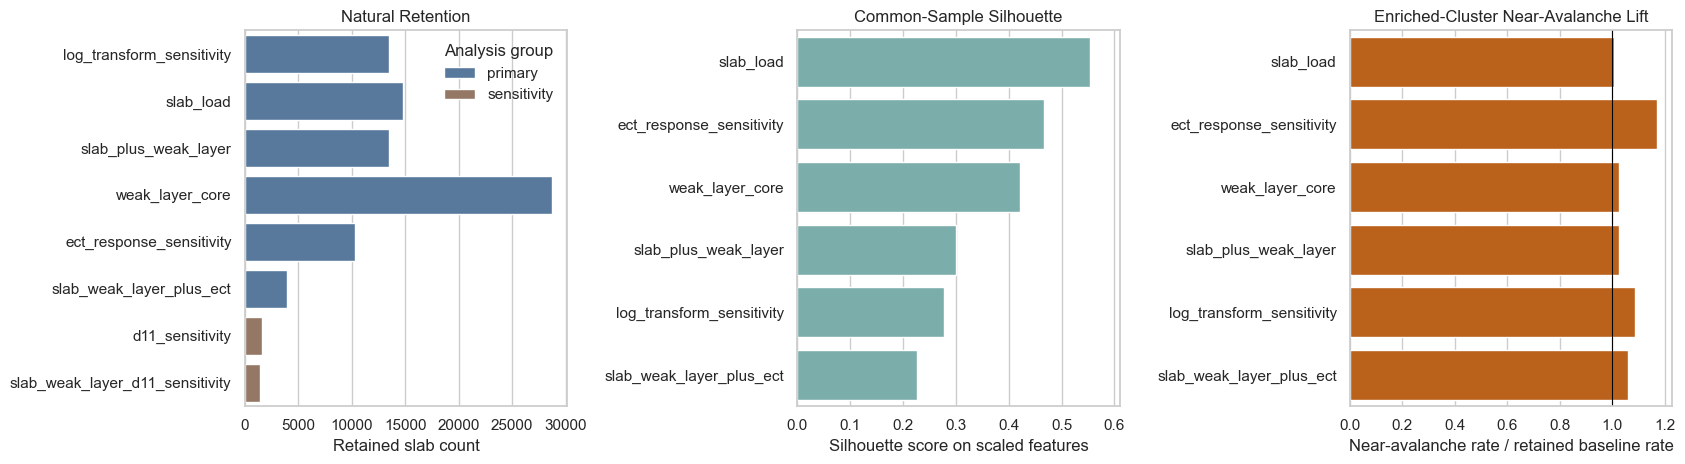

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

sns.barplot(
    data=natural_retention_summary_df,
    x="total_slabs_retained",
    y="feature_set",
    hue="analysis_group",
    dodge=False,
    palette={"primary": "#4C78A8", "sensitivity": "#9D755D"},
    ax=axes[0],
)
axes[0].set_title("Natural Retention")
axes[0].set_xlabel("Retained slab count")
axes[0].set_ylabel("")
axes[0].legend(title="Analysis group", frameon=False)

sns.barplot(
    data=common_sample_summary_df,
    x="kmeans_silhouette_score",
    y="feature_set",
    color="#72B7B2",
    ax=axes[1],
)
axes[1].set_title("Common-Sample Silhouette")
axes[1].set_xlabel("Silhouette score on scaled features")
axes[1].set_ylabel("")
axes[1].set_xlim(0, max(0.05, common_sample_summary_df["kmeans_silhouette_score"].max() * 1.1))

sns.barplot(
    data=common_sample_summary_df,
    x="enriched_cluster_rate_lift",
    y="feature_set",
    color="#D55E00",
    ax=axes[2],
)
axes[2].axvline(1, color="black", linewidth=0.8)
axes[2].set_title("Enriched-Cluster Near-Avalanche Lift")
axes[2].set_xlabel("Near-avalanche rate / retained baseline rate")
axes[2].set_ylabel("")

fig.tight_layout()


## Appendix: Presentation Content

## Background on K-Means Clustering
- K-means is an unsupervised clustering algorithm that partitions observations into a specified number of groups based on feature similarity.
- For this analysis, each slab is represented by a selected feature set, features are standardized, and K-means is run with K=2 for a consistent feature-set comparison.
- The algorithm assigns slabs to clusters by minimizing within-cluster distance to each cluster centroid; avalanche context is not used as an input.
- Important considerations: K must be chosen ahead of time, results depend on feature scaling and feature selection, and clusters should not be interpreted as validated classes without external labels.
- Silhouette score measures how well each slab fits its assigned cluster relative to the neighboring cluster. Scores range from -1 to 1, with higher values indicating clearer separation.
- In this presentation, silhouette score is used as a feature-space separation diagnostic, not as a direct measure of avalanche prediction performance.

## Description of dataset
- Source data: SnowPylot CAAML files from `snowpits/2015_2025`.
- Parsed dataset size: 50,278 SnowPylot pits, all converted into SnowPyt-MechParams pit objects.
- Usable analysis units: 34,690 slabs created from the layer of concern.
- Avalanche-context label: 1,381 slabs are marked as near an avalanche; 33,309 slabs have unknown or unrecorded avalanche context.
- Interpretation of labels: near-avalanche slabs are treated as known unstable examples, while unlabeled slabs are treated as unknown context rather than stable negatives.
- Feature families available for clustering include slab load and structure, weak-layer geometry and hand hardness, persistent grain flag, log-transformed physical features, ECT summaries, and D11 bending stiffness.
- Feature coverage varies substantially: weak-layer geometry is broadly available, slab weight and ECT features have moderate coverage, and D11 has very low coverage.

## Idea 
- Pits marked as near an avalanche likely represent a subset of slabs with unstable characteristics.
- The analysis asks whether any feature set separates the slabs into two K-means clusters where one cluster is enriched in these known near-avalanche examples.
- A useful feature set would ideally produce both clear feature-space separation and meaningful near-avalanche enrichment after clustering.
- Clear separation is summarized with the K-means silhouette score.
- Near-avalanche enrichment is summarized with the near-avalanche rate in the enriched cluster, the lift relative to the retained baseline rate, and the share of near-avalanche slabs captured by that cluster.
- The enriched cluster should be described as a near-avalanche enriched cluster, not as an unstable cluster, because unlabeled slabs are not confirmed stable examples.
- The results should be framed as exploratory feature-set diagnostics rather than a validated operational stability classifier.

## Analysis outline
- Parse CAAML pits using SnowPylot utilities and convert parsed pits into SnowPyt-MechParams pit objects.
- Create slabs from the layer of concern and keep pit/slab identifiers plus avalanche-context metadata for post-clustering diagnostics.
- Engineer slab-level features: slab thickness, slab weight, layer count, cumulative hand-hardness index, mean slab hand hardness, and D11 bending stiffness.
- Engineer weak-layer features: weak-layer top depth, weak-layer thickness, weak-layer hand-hardness index, and persistent grain flag.
- Parse ECT results into numeric summaries, including propagation rate, mean taps, mean propagating taps, and an instability index.
- Define feature sets for comparison: slab load, weak-layer core, slab plus weak layer, log-transform sensitivity, ECT response sensitivity, slab/weak-layer/ECT combination, and D11 sensitivity sets.
- Filter to complete cases for each feature set, standardize selected features, and apply K-means with K=2.
- Rank primary feature sets on one shared complete-case sample so results reflect feature choice rather than different retained-row populations.
- Use natural-retention results separately to show practical coverage and applicability.
- Assign the near-avalanche enriched cluster after clustering by selecting the cluster with the higher near-avalanche rate.

## Results
- Dataset snapshot table: 50,278 parsed pits, 34,690 usable slabs, and 1,381 slabs marked near avalanche.
- Feature coverage table or chart: weak-layer geometry has high coverage, slab weight and ECT features have moderate coverage, and D11 has very low coverage.
- Primary common-sample comparison uses 3,914 retained slabs with 213 near-avalanche slabs and a 5.44% retained baseline near-avalanche rate.
- Main ranking table should include feature set, number of features, retained slabs, near-avalanche slabs retained, silhouette score, enriched-cluster near-avalanche rate, lift, and capture share.
- Key common-sample result: slab-load features have the strongest silhouette score (0.555) but almost no near-avalanche lift (1.01x).
- Key common-sample result: ECT response features have the highest near-avalanche lift (1.17x), but the enrichment remains modest.
- Key common-sample result: combined physical and ECT feature sets do not automatically improve silhouette or enrichment.
- Natural-retention figure should show retained slab counts by feature set, highlighting that weak-layer core retains the most slabs while D11 sensitivity sets retain only about 4-5% of usable slabs.
- Common-sample figure should show silhouette scores and enriched-cluster near-avalanche lift side by side so the separation/enrichment tradeoff is visible.
- Interpretation: K-means identifies feature-space structure, but near-avalanche enrichment is weak; results are most useful for choosing feature sets and designing follow-up analyses.
- Recommended next steps: refine avalanche-context labels, test additional K values or non-spherical clustering methods, and only move to supervised evaluation if reliable stable/unstable labels become available.
